# Simulation PSF Benchmark

This notebook benchmarks simple PSF models on **synthetic** images only.

This is a **controlled single-stamp benchmark / calibration notebook**:
- it is **not** the real-data visit-screening pipeline
- it is designed to calibrate which stamp-level metrics respond to controlled Gaussian deviations
- the current first-pass focus is radial heavy-wing structure under clean, known conditions

The goal of this first benchmark is to isolate one controlled deviation at a time and ask:
- If the PSF is a perfect 2D Gaussian, which models fit similarly well?
- If the PSF develops heavier radial wings, which model gains an advantage?

This notebook is intentionally simple:
- fixed image size
- fixed known center
- no noise
- unit total flux normalization
- no Butler, TAP, DP1, or Rubin data-loading code

The heavy-wing cases are **not** generated as exact double Gaussians, so the benchmark does not trivially favor the Double Gaussian fit family.


## 1. Setup


In [80]:
from pathlib import Path
import sys
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import OptimizeWarning

cwd = Path.cwd().resolve()
candidate_roots = [
    cwd,
    cwd.parent if cwd.name == "notebooks" else None,
    cwd / "Rubin-PSF-Analysis",
]
repo_root = None
for candidate in candidate_roots:
    if candidate is not None and (candidate / "src" / "simulationTools.py").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate Rubin-PSF-Analysis repo root from the current working directory.")

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import simulationTools
importlib.reload(simulationTools)

from simulationTools import (
    MODEL_LABELS,
    MODEL_ORDER,
    image_center_from_shape,
    normalize_flux,
    make_gaussian_psf,
    make_heavy_wing_psf,
    make_elliptical_gaussian_psf,
    make_elliptical_heavy_wing_psf,
    make_elliptical_double_gaussian_psf,
    add_poisson_like_gaussian_noise,
    show_psf,
    analyze_simulated_psf,
    print_available_chi2,
    build_summary_row,
    build_reference_metric_row,
    run_named_synthetic_case,
    plot_case_profiles,
    plot_residual_comparison,
    plot_chi_summary,
    plot_best_model_counts,
    run_heavy_wing_parameter_scan,
    plot_best_model_heatmap,
    plot_ng_score_heatmap,
)

warnings.filterwarnings("ignore", category=OptimizeWarning)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
plt.rcParams["axes.grid"] = False


## 2. Benchmark design

This notebook keeps the benchmark intentionally controlled:
- the simulated PSFs are centered on one known image center
- the images are noiseless and background-free
- all model fits use the same fixed center and zero background in benchmark mode
- a single-Gaussian baseline is included for comparison

The heavy-wing cases are generated as a Gaussian-like core plus an exponential-like radial tail, so they are not exact double-Gaussian truth images.

For interpretation, it is useful to separate the models into two roles:
- **Gaussian / Double Gaussian / Moffat** act as candidate operational models for compact radial PSF descriptions
- **Gauss-Hermite / Shapelet** act as more flexible reference models that can absorb structure more easily

That distinction matters here because the current synthetic truth family is radially symmetric and heavy-winged, which is naturally closer to Double Gaussian or Moffat than to the main strengths of Gauss-Hermite or Shapelet.


In [81]:
size = 25
sigma_core = 2.0
shared_center = image_center_from_shape((size, size))
wing_scale = 3.0

controlled_fit_center = False
controlled_fit_background = False
core_radius = 2.0
wing_radius = 3.0
shapelet_beta = 2.0
shapelet_nmax = 6

scan_wing_strength_values = np.array([0.00, 0.01, 0.05, 0.10, 0.20, 0.40, 0.70])
scan_wing_scale_values = np.array([2.0, 2.5, 3.0, 4.0, 5.0])

print("Image size:", (size, size))
print("Shared center:", shared_center)
print("Core sigma:", sigma_core)
print("Controlled fit_center:", controlled_fit_center)
print("Controlled fit_background:", controlled_fit_background)
print("Core radius for metrics:", core_radius)
print("Wing radius for metrics:", wing_radius)
print("Shapelet beta:", shapelet_beta)
print("Shapelet nmax:", shapelet_nmax)
print("Scan wing_strength values:", scan_wing_strength_values)
print("Scan wing_scale values:", scan_wing_scale_values)


Image size: (25, 25)
Shared center: (12.0, 12.0)
Core sigma: 2.0
Controlled fit_center: False
Controlled fit_background: False
Core radius for metrics: 2.0
Wing radius for metrics: 3.0
Shapelet beta: 2.0
Shapelet nmax: 6
Scan wing_strength values: [0.   0.01 0.05 0.1  0.2  0.4  0.7 ]
Scan wing_scale values: [2.  2.5 3.  4.  5. ]


## 3. Single-image sanity check

Run the full controlled benchmark path on one pure Gaussian image. This checks that the fitting pipeline, success metadata, and summary metrics all work before scanning multiple cases.


Gaussian         chi-like score: 1.7508e-37   [valid]
Double Gaussian  chi-like score: 2.0088e-19   [valid]
Gauss-Hermite    chi-like score: 1.7508e-37   [valid]
Moffat           chi-like score: 5.0973e-09   [valid]
Shapelet         chi-like score: 1.1279e-33   [valid]
Best model: gaussian
Non-Gaussian score: -11.3029


,best_model,gaussian_chi2,dg_chi2,gh_chi2,moffat_chi2,shapelet_chi2,ng_score,gaussian_fit_valid,dg_fit_valid,gh_fit_valid,moffat_fit_valid,shapelet_fit_valid
0,gaussian,1.750755e-37,2.008817e-19,1.750755e-37,5.097274e-09,1.127938e-33,-11.30294,True,True,True,True,True


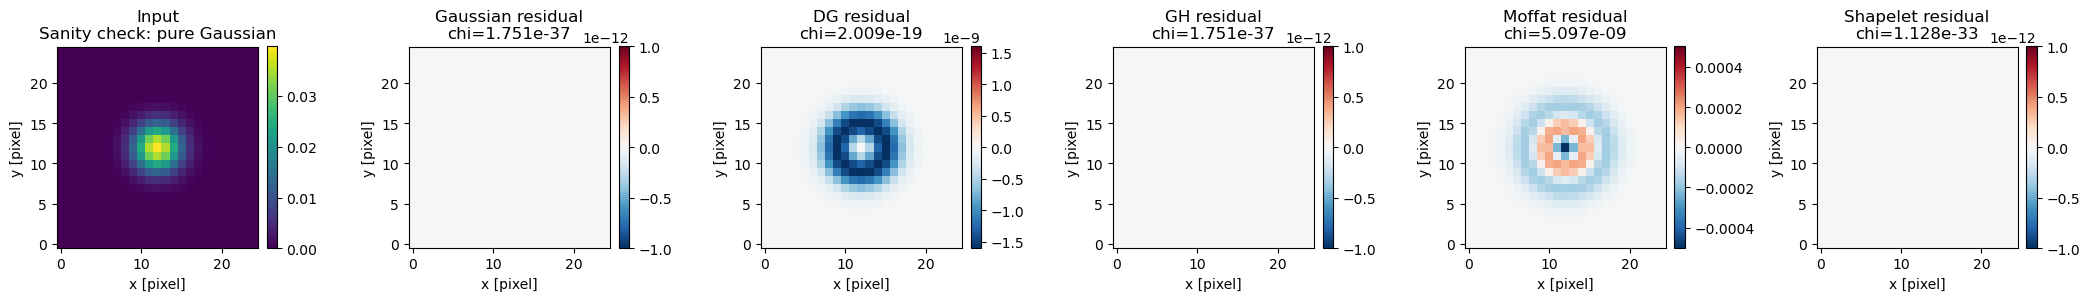

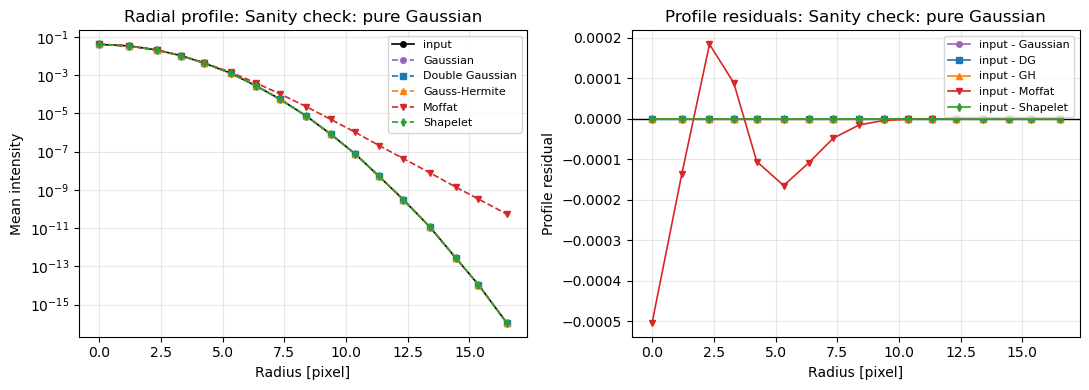

In [82]:
sanity_image = make_gaussian_psf(size=size, sigma=sigma_core, center=shared_center)
sanity_result = analyze_simulated_psf(
    sanity_image,
    sigma_hint=sigma_core,
    center=shared_center,
    shapelet_beta=shapelet_beta,
    shapelet_nmax=shapelet_nmax,
    fit_center=controlled_fit_center,
    fit_background=controlled_fit_background,
    core_radius=core_radius,
    wing_radius=wing_radius,
)

print_available_chi2(sanity_result)

display(
    pd.DataFrame(
        [
            {
                "best_model": sanity_result["best_model"],
                "gaussian_chi2": sanity_result["gaussian_chi2"],
                "dg_chi2": sanity_result["dg_chi2"],
                "gh_chi2": sanity_result["gh_chi2"],
                "moffat_chi2": sanity_result["moffat_chi2"],
                "shapelet_chi2": sanity_result["shapelet_chi2"],
                "ng_score": sanity_result["ng_score"],
                "gaussian_fit_valid": sanity_result["gaussian_fit_valid"],
                "dg_fit_valid": sanity_result["dg_fit_valid"],
                "gh_fit_valid": sanity_result["gh_fit_valid"],
                "moffat_fit_valid": sanity_result["moffat_fit_valid"],
                "shapelet_fit_valid": sanity_result["shapelet_fit_valid"],
            }
        ]
    )
)

plot_residual_comparison(sanity_result, "Sanity check: pure Gaussian")
plot_case_profiles(sanity_result, "Sanity check: pure Gaussian", log_y=True)


## 4. Define benchmark cases


In [83]:
benchmark_cases = [
    {
        "case_name": "Case 0: Pure Gaussian",
        "deviation_type": "pure_gaussian",
        "image": make_gaussian_psf(size=size, sigma=sigma_core, center=shared_center),
        "generation_params": {"sigma": sigma_core},
    },
    {
        "case_name": "Case 1: Weak heavy wings",
        "deviation_type": "heavy_wings",
        "image": make_heavy_wing_psf(
            size=size,
            sigma_core=sigma_core,
            wing_strength=0.10,
            wing_scale=wing_scale,
            center=shared_center,
        ),
        "generation_params": {"sigma_core": sigma_core, "wing_strength": 0.10, "wing_scale": wing_scale},
    },
    {
        "case_name": "Case 2: Medium heavy wings",
        "deviation_type": "heavy_wings",
        "image": make_heavy_wing_psf(
            size=size,
            sigma_core=sigma_core,
            wing_strength=0.25,
            wing_scale=wing_scale,
            center=shared_center,
        ),
        "generation_params": {"sigma_core": sigma_core, "wing_strength": 0.25, "wing_scale": wing_scale},
    },
    {
        "case_name": "Case 3: Strong heavy wings",
        "deviation_type": "heavy_wings",
        "image": make_heavy_wing_psf(
            size=size,
            sigma_core=sigma_core,
            wing_strength=0.70,
            wing_scale=wing_scale,
            center=shared_center,
        ),
        "generation_params": {"sigma_core": sigma_core, "wing_strength": 0.70, "wing_scale": wing_scale},
    },
]


In [84]:
case_overview_rows = []
for case in benchmark_cases:
    row = {
        "case_name": case["case_name"],
        "deviation_type": case["deviation_type"],
        **case["generation_params"],
    }
    case_overview_rows.append(row)

case_overview_df = pd.DataFrame(case_overview_rows)
case_overview_df


,case_name,deviation_type,sigma,sigma_core,wing_strength,wing_scale
0,Case 0: Pure Gaussian,pure_gaussian,2.0,NaN,NaN,NaN
1,Case 1: Weak heavy wings,heavy_wings,NaN,2.0,0.10,3.0
2,Case 2: Medium heavy wings,heavy_wings,NaN,2.0,0.25,3.0
3,Case 3: Strong heavy wings,heavy_wings,NaN,2.0,0.70,3.0


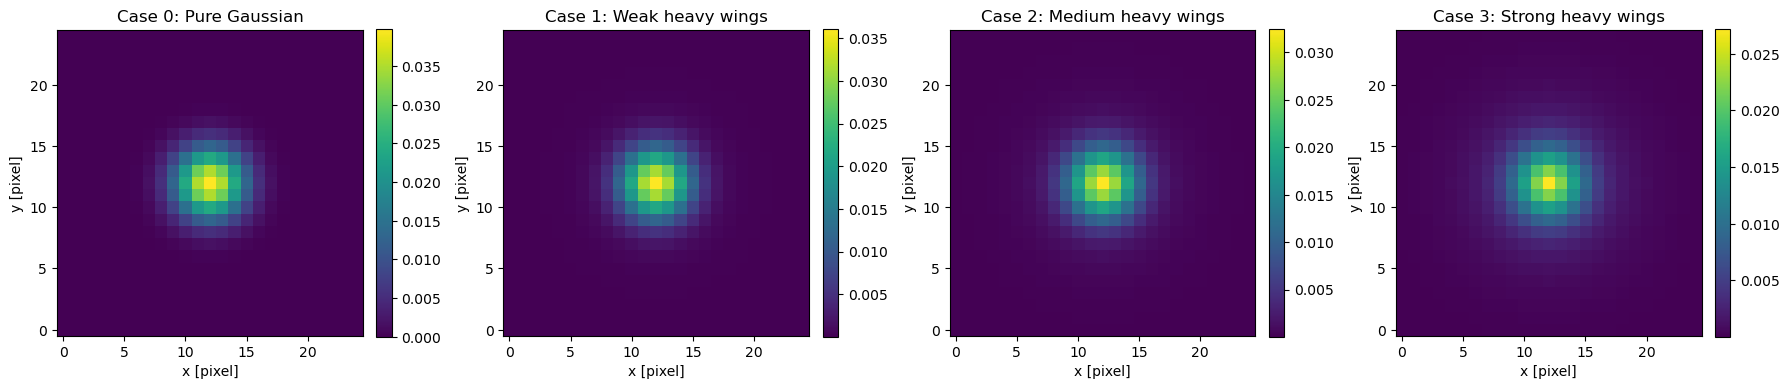

In [85]:
fig, axes = plt.subplots(1, len(benchmark_cases), figsize=(18, 4))
for ax, case in zip(axes, benchmark_cases):
    show_psf(case["image"], title=case["case_name"], ax=ax)
plt.tight_layout()
plt.show()


## 5. Run all benchmark cases

Each case is analyzed with the same controlled configuration:
- same known center
- no fitted center shift
- no fitted background
- same core/wing/profile diagnostics

This keeps the comparison fair across model families.


In [86]:
benchmark_results = []
summary_rows = []

for case in benchmark_cases:
    result = analyze_simulated_psf(
        case["image"],
        sigma_hint=sigma_core,
        center=shared_center,
        shapelet_beta=shapelet_beta,
        shapelet_nmax=shapelet_nmax,
        fit_center=controlled_fit_center,
        fit_background=controlled_fit_background,
        core_radius=core_radius,
        wing_radius=wing_radius,
    )
    result["case_name"] = case["case_name"]
    result["deviation_type"] = case["deviation_type"]
    result["generation_params"] = case["generation_params"]

    benchmark_results.append(result)
    summary_rows.append(build_summary_row(case, result))

print(f"Ran {len(benchmark_results)} synthetic benchmark cases.")


Ran 4 synthetic benchmark cases.


## 6. Summary table

The summary table keeps the original case-based comparison readable, but now includes:
- the Gaussian baseline
- fit-valid flags
- core / wing / profile diagnostics
- a provisional non-Gaussian score


In [87]:
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.merge(case_overview_df, on=["case_name", "deviation_type"], how="left")

summary_columns = [
    "case_name",
    "best_model",
    "ng_score",
    "gaussian_chi2",
    "dg_chi2",
    "gh_chi2",
    "moffat_chi2",
    "shapelet_chi2",
    "gaussian_core_mse",
    "gaussian_wing_mse",
    "dg_wing_mse",
    "moffat_wing_mse",
    "gaussian_profile_mse",
    "dg_profile_mse",
    "moffat_profile_mse",
    "gaussian_fit_valid",
    "dg_fit_valid",
    "gh_fit_valid",
    "moffat_fit_valid",
    "shapelet_fit_valid",
    "delta_gaussian_vs_dg",
    "delta_gaussian_vs_moffat",
]

summary_df_display = summary_df[summary_columns].copy()
float_cols = summary_df_display.select_dtypes(include=[float, np.floating]).columns
for col in float_cols:
    summary_df_display[col] = summary_df_display[col].map(lambda value: f"{value:.3e}" if pd.notnull(value) else "nan")

display(summary_df_display)


,case_name,best_model,ng_score,gaussian_chi2,dg_chi2,gh_chi2,moffat_chi2,shapelet_chi2,gaussian_core_mse,gaussian_wing_mse,...,gaussian_profile_mse,dg_profile_mse,moffat_profile_mse,gaussian_fit_valid,dg_fit_valid,gh_fit_valid,moffat_fit_valid,shapelet_fit_valid,delta_gaussian_vs_dg,delta_gaussian_vs_moffat
0,Case 0: Pure Gaussian,gaussian,-1.130e+01,1.751e-37,2.009e-19,1.751e-37,5.097e-09,1.128e-33,0.000e+00,2.188e-38,...,7.081e-37,3.712e-19,2.154e-08,True,True,True,True,True,-2.009e-19,-5.097e-09
1,Case 1: Weak heavy wings,double_gaussian,1.373e+00,2.811e-08,1.190e-09,1.494e-08,8.316e-09,8.134e-09,1.918e-07,2.492e-08,...,1.075e-07,2.664e-08,9.112e-09,True,True,True,True,True,2.692e-08,1.980e-08
2,Case 2: Medium heavy wings,double_gaussian,1.352e+00,1.043e-07,4.643e-09,5.182e-08,1.723e-08,3.187e-08,8.176e-07,9.085e-08,...,4.347e-07,1.033e-07,2.393e-08,True,True,True,True,True,9.967e-08,8.708e-08
3,Case 3: Strong heavy wings,moffat,1.428e+00,2.688e-07,1.363e-08,1.140e-07,1.003e-08,9.466e-08,2.913e-06,2.229e-07,...,1.376e-06,2.981e-07,6.953e-08,True,True,True,True,True,2.552e-07,2.588e-07


### Reference metric ranges for later real-data interpretation

This compact table keeps only the most directly interpretable representative-case metrics.
It is meant to serve as a quick calibration reference when later reading real observed-star diagnostics.


In [88]:
reference_metric_ranges_df = pd.DataFrame(
    [
        build_reference_metric_row(case["case_name"], case["deviation_type"], result)
        for case, result in zip(benchmark_cases, benchmark_results)
    ]
)

reference_metric_ranges_df = reference_metric_ranges_df[
    [
        "case_name",
        "best_model",
        "gaussian_chi2",
        "dg_chi2",
        "moffat_chi2",
        "ng_score",
        "gaussian_wing_mse",
        "dg_wing_mse",
        "moffat_wing_mse",
    ]
]

display(reference_metric_ranges_df)


,case_name,best_model,gaussian_chi2,dg_chi2,moffat_chi2,ng_score,gaussian_wing_mse,dg_wing_mse,moffat_wing_mse
0,Case 0: Pure Gaussian,gaussian,1.750755e-37,2.008817e-19,5.097274e-09,-11.302940,2.187614e-38,1.479925e-19,3.613656e-09
1,Case 1: Weak heavy wings,double_gaussian,2.811460e-08,1.190282e-09,8.316304e-09,1.373282,2.492499e-08,3.153314e-10,7.948235e-09
2,Case 2: Medium heavy wings,double_gaussian,1.043103e-07,4.642686e-09,1.723208e-08,1.351558,9.084785e-08,1.253828e-09,1.516830e-08
3,Case 3: Strong heavy wings,moffat,2.688179e-07,1.362886e-08,1.003195e-08,1.428073,2.228938e-07,3.865184e-09,5.780161e-09


## 7. Summary plots

These plots summarize which models win under the four representative cases, and whether the heavy-wing deviations create a clear advantage over the Gaussian baseline.

In this notebook, Gaussian / Double Gaussian / Moffat should be read as the more operational radial model candidates, while Gauss-Hermite / Shapelet are better interpreted as flexible reference models.


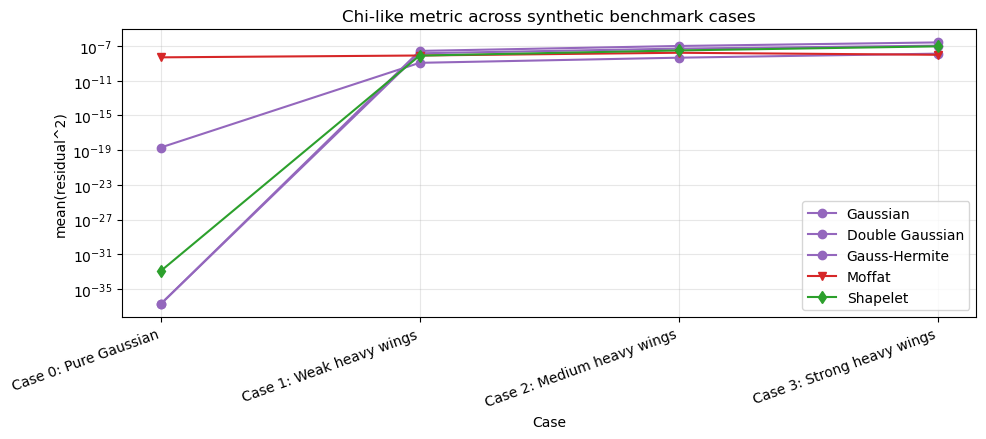

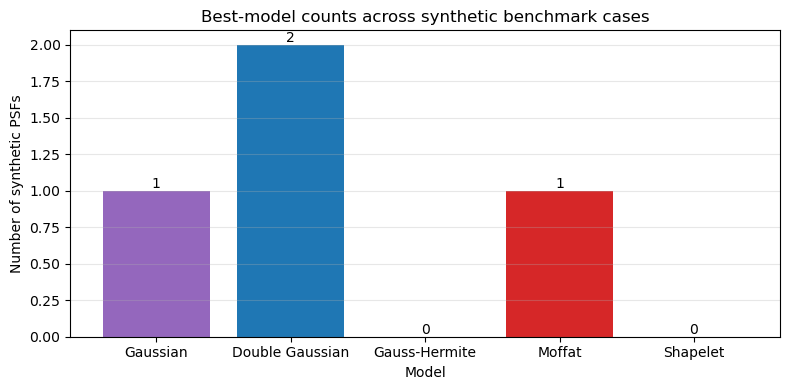

,case_name,best_model,ng_score,delta_gaussian_vs_dg,delta_gaussian_vs_moffat
0,Case 0: Pure Gaussian,gaussian,-11.302940,-2.008817e-19,-5.097274e-09
1,Case 1: Weak heavy wings,double_gaussian,1.373282,2.692432e-08,1.979830e-08
2,Case 2: Medium heavy wings,double_gaussian,1.351558,9.966766e-08,8.707826e-08
3,Case 3: Strong heavy wings,moffat,1.428073,2.551891e-07,2.587860e-07


In [89]:
plot_chi_summary(summary_df)
best_counts = plot_best_model_counts(benchmark_results)

display(
    summary_df[
        [
            "case_name",
            "best_model",
            "ng_score",
            "delta_gaussian_vs_dg",
            "delta_gaussian_vs_moffat",
        ]
    ]
)


## 8. Representative diagnostics

Inspect two representative cases:
- the pure Gaussian baseline
- the strongest heavy-wing case

Residual images test where each model misses structure, while the profile panel shows whether the disagreement is concentrated in the core or wings.

For the heavy-wing family, the most important operational comparison is usually Gaussian vs Double Gaussian vs Moffat; Gauss-Hermite and Shapelet are mainly included here as flexible references.


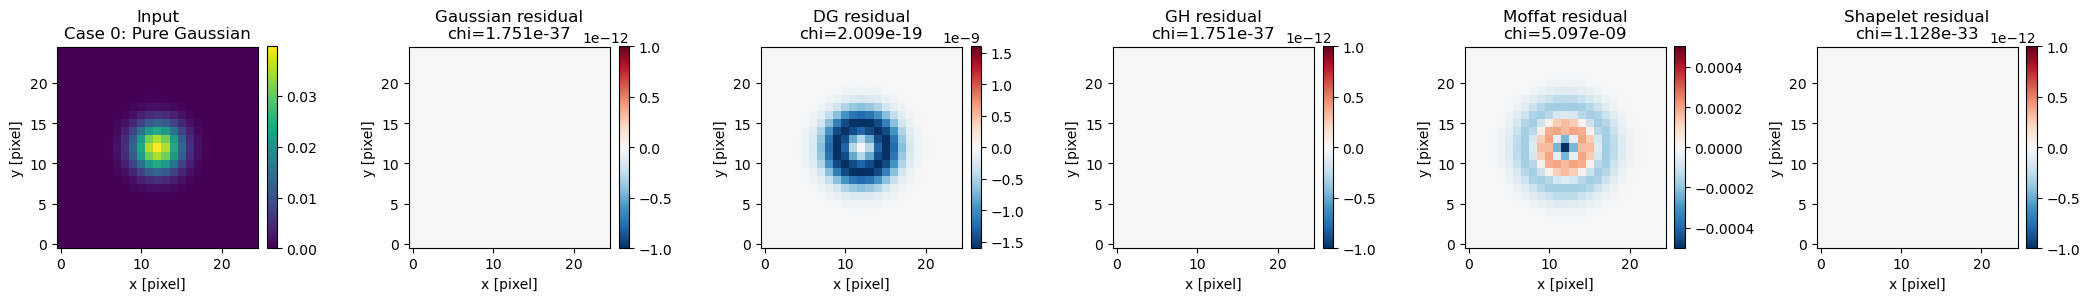

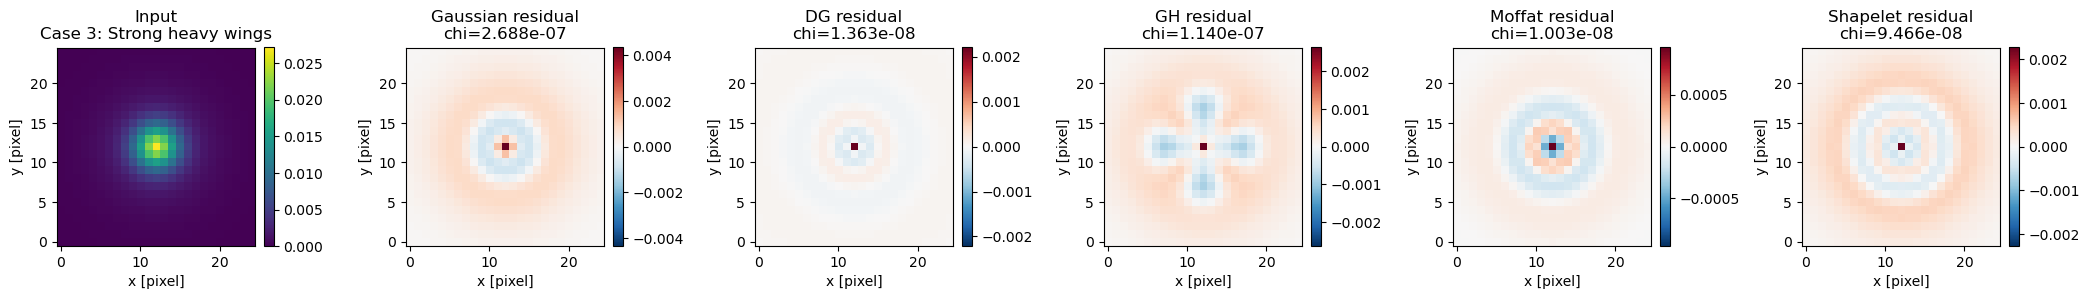

In [90]:
pure_result = next(r for r in benchmark_results if r["case_name"] == "Case 0: Pure Gaussian")
strong_result = next(r for r in benchmark_results if r["case_name"] == "Case 3: Strong heavy wings")

plot_residual_comparison(pure_result, pure_result["case_name"])
plot_residual_comparison(strong_result, strong_result["case_name"])


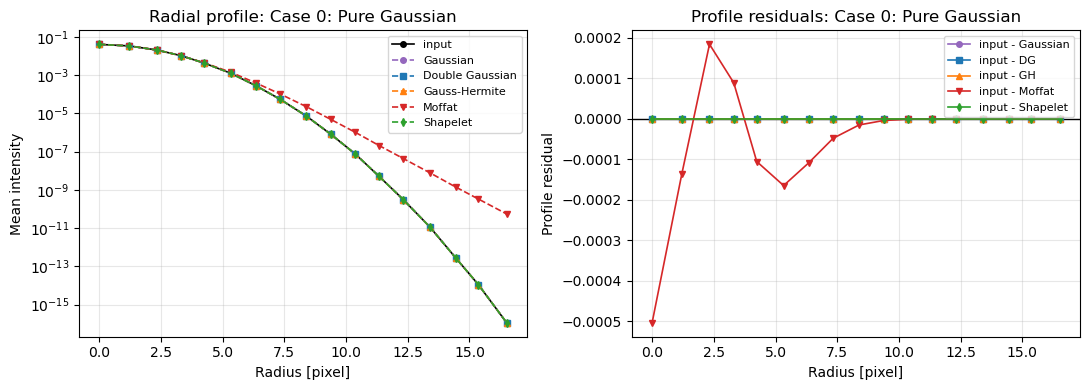

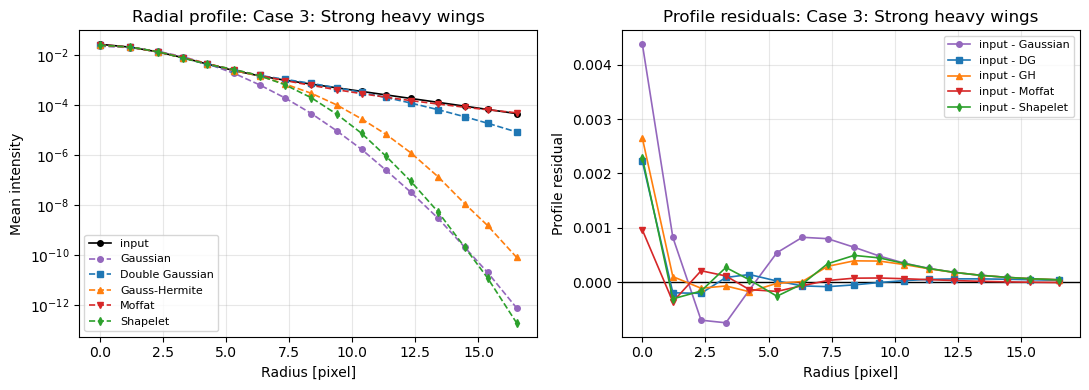

In [91]:
plot_case_profiles(pure_result, pure_result["case_name"], log_y=True)
plot_case_profiles(strong_result, strong_result["case_name"], log_y=True)


## 9. 2D heavy-wing parameter scan

After the four hand-picked cases, run a controlled scan over `(wing_strength, wing_scale)`.
Including `wing_strength = 0.00` and `0.01` makes it possible to see where the benchmark starts to depart from the nearly Gaussian regime.

This scan maps where each model becomes advantageous and where the synthetic PSF starts to look clearly non-Gaussian.


In [92]:
scan_df = run_heavy_wing_parameter_scan(
    size=size,
    sigma_core=sigma_core,
    wing_strength_values=scan_wing_strength_values,
    wing_scale_values=scan_wing_scale_values,
    center=shared_center,
    shapelet_beta=shapelet_beta,
    shapelet_nmax=shapelet_nmax,
    fit_center=controlled_fit_center,
    fit_background=controlled_fit_background,
    core_radius=core_radius,
    wing_radius=wing_radius,
)

print(f"Ran {len(scan_df)} points in the heavy-wing scan.")

display(
    scan_df[
        [
            "wing_strength",
            "wing_scale",
            "best_model",
            "ng_score",
            "gaussian_chi2",
            "dg_chi2",
            "moffat_chi2",
            "gh_chi2",
            "shapelet_chi2",
        ]
    ]
)


Ran 35 points in the heavy-wing scan.


,wing_strength,wing_scale,best_model,ng_score,gaussian_chi2,dg_chi2,moffat_chi2,gh_chi2,shapelet_chi2
0,0.00,2.0,gaussian,-11.302917,4.936774e-37,2.008710e-19,5.097274e-09,4.936774e-37,1.091155e-33
1,0.00,2.5,gaussian,-11.302917,4.936774e-37,2.008710e-19,5.097274e-09,4.936774e-37,1.091155e-33
2,0.00,3.0,gaussian,-11.302917,4.936774e-37,2.008710e-19,5.097274e-09,4.936774e-37,1.091155e-33
3,0.00,4.0,gaussian,-11.302917,4.936774e-37,2.008710e-19,5.097274e-09,4.936774e-37,1.091155e-33
4,0.00,5.0,gaussian,-11.302917,4.936774e-37,2.008710e-19,5.097274e-09,4.936774e-37,1.091155e-33
5,0.01,2.0,double_gaussian,0.565001,8.625399e-11,2.348434e-11,4.008737e-09,3.927240e-11,2.362469e-11
6,0.01,2.5,double_gaussian,0.974740,1.873394e-10,1.985590e-11,3.553159e-09,8.902200e-11,4.470774e-11
7,0.01,3.0,double_gaussian,1.387024,4.102870e-10,1.682922e-11,3.120653e-09,2.273397e-10,1.146755e-10
8,0.01,4.0,double_gaussian,1.938877,1.317322e-09,1.516406e-11,2.684380e-09,8.783148e-10,5.048968e-10
9,0.01,5.0,double_gaussian,2.246062,2.836795e-09,1.609778e-11,2.999932e-09,2.071053e-09,1.315632e-09


## 10. Scan heatmaps

The heatmaps summarize the controlled scan in two complementary ways:
- **best-model heatmap**: which model wins at each `(wing_strength, wing_scale)` point
- **ng_score heatmap**: how strongly the benchmark prefers a non-Gaussian wing-aware model over a single Gaussian baseline

When reading these maps, it is useful to treat Gauss-Hermite and Shapelet as flexible references, while the more operational radial comparison is Gaussian vs Double Gaussian vs Moffat.


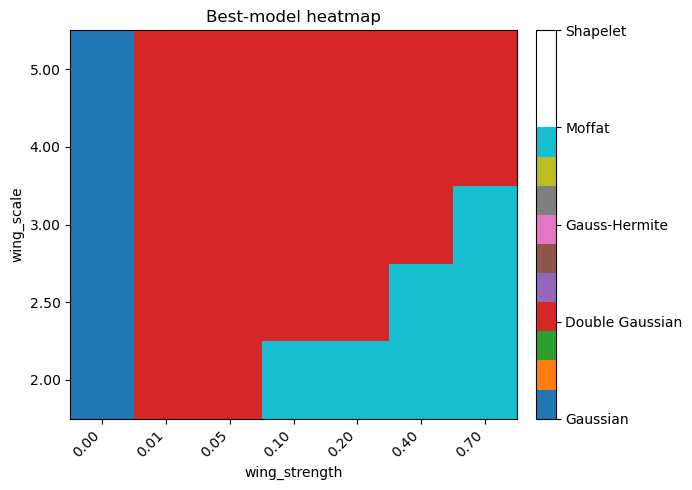

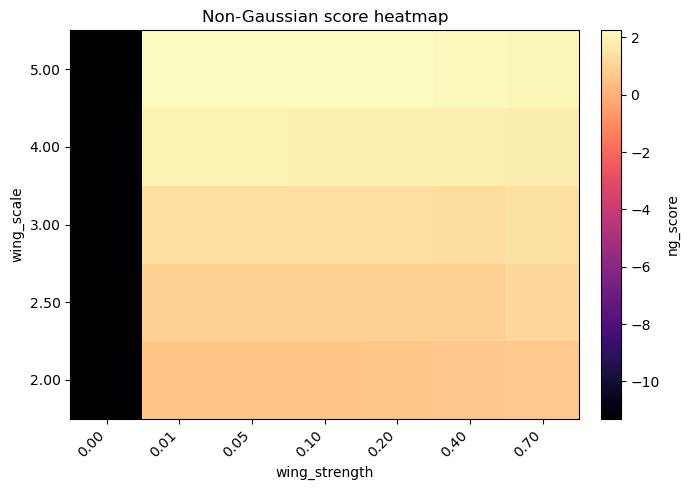

best_model
double_gaussian    23
gaussian            5
moffat              7
Name: count, dtype: int64

In [93]:
plot_best_model_heatmap(scan_df)
plot_ng_score_heatmap(scan_df)

display(scan_df.groupby("best_model").size().rename("count"))


## 11. What to inspect

When reading the outputs, focus on these questions:
- In the pure Gaussian case, does the Gaussian baseline perform as well as the more flexible models?
- Once `wing_strength` moves from `0.00` / `0.01` upward, where does the benchmark start to leave the nearly Gaussian regime?
- As heavy wings increase, do Double Gaussian or Moffat gain a clear advantage in wing-sensitive metrics?
- Do the residual images and log-profile plots agree about where each model fails?
- Does `ng_score` increase as the synthetic PSF becomes more non-Gaussian in its tails?
- In the 2D scan, do the best-model regions transition smoothly with `(wing_strength, wing_scale)`?


## 12. How these synthetic diagnostics will be used in real visit screening

This synthetic notebook stays at the **single-stamp calibration** level. Its job is to tell us which metrics are sensitive to which PSF deviations before we move to detector-level or visit-level screening.

The mapping to the real-data project is:
- **`ng_score`**: sensitivity to non-Gaussian / heavy-wing behavior in an observed star stamp
- **core / wing / profile diagnostics**: where the model mismatch lives, i.e. whether the disagreement is concentrated in the central core, the outer wings, or the radial profile as a whole
- **ellipticity / second-moment shape metrics**: sensitivity to shape excursions and anisotropy
- **detector / visit spread metrics**: sensitivity to spatial nonuniformity when many stars are aggregated across a detector or an entire visit

So this notebook does not screen visits directly. Instead, it calibrates the stamp-level metrics that later feed into detector-level and visit-level badness ranking.


## 13. Next synthetic deviation families

Heavy-wing deviations remain the **current calibrated family** for this notebook. That is the main story we use to interpret `ng_score`, wing-sensitive residual metrics, and model-comparison behavior.

The next synthetic family is **ellipticity / anisotropy**, motivated by real bad visits seen in the advisor's movie. The small demonstration below is intentionally lightweight: it just shows that the same single-stamp framework can already analyze non-round PSFs too.


In [94]:
extra_cases = [
    {
        "case_name": "Demo: Elliptical Gaussian",
        "deviation_type": "elliptical_gaussian",
        "image": make_elliptical_gaussian_psf(
            size=size,
            sigma_x=sigma_core * 1.25,
            sigma_y=sigma_core * 0.85,
            theta=np.deg2rad(25.0),
            center=shared_center,
        ),
    },
    {
        "case_name": "Demo: Elliptical heavy wings",
        "deviation_type": "elliptical_heavy_wing",
        "image": make_elliptical_heavy_wing_psf(
            size=size,
            sigma_x=sigma_core * 1.20,
            sigma_y=sigma_core * 0.80,
            theta=np.deg2rad(25.0),
            wing_strength=0.25,
            wing_scale=4.0,
            center=shared_center,
        ),
    },
]

fig, axes = plt.subplots(1, len(extra_cases), figsize=(8, 3.5))
for ax, case in zip(np.atleast_1d(axes), extra_cases):
    im = ax.imshow(case["image"], cmap="viridis")
    ax.set_title(case["case_name"], fontsize=10)
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

extra_case_rows = []
for case in extra_cases:
    row = run_named_synthetic_case(
        case["image"],
        case_name=case["case_name"],
        deviation_type=case["deviation_type"],
        sigma_hint=sigma_core,
        center=shared_center,
        shapelet_beta=shapelet_beta,
        shapelet_nmax=shapelet_nmax,
        fit_center=controlled_fit_center,
        fit_background=controlled_fit_background,
        core_radius=core_radius,
        wing_radius=wing_radius,
    )
    extra_case_rows.append({k: v for k, v in row.items() if k != "result"})

extra_case_df = pd.DataFrame(extra_case_rows)[
    [
        "case_name",
        "deviation_type",
        "best_model",
        "gaussian_chi2",
        "dg_chi2",
        "moffat_chi2",
        "ng_score",
        "ellipticity",
        "fwhm_proxy",
        "ee80_radius",
        "gaussian_wing_mse",
        "dg_wing_mse",
        "moffat_wing_mse",
    ]
]

display(extra_case_df)



TypeError: make_elliptical_gaussian_psf() got an unexpected keyword argument 'sigma_major'

## 14. When to use this notebook vs the DP1 screening notebook

Use **this synthetic notebook** when you want to:
- calibrate how single-stamp metrics respond to controlled PSF deviations
- test fitting logic, residual behavior, and metric sensitivity in a clean setting
- understand what `ng_score`, wing-sensitive metrics, shape metrics, and profile diagnostics mean before moving to real observed stars

Use the **DP1 screening notebook** when you want to:
- analyze real observed star cutouts from Rubin DP1 visit images
- aggregate star-level behavior up to detector-level and visit-level screening
- rank visits by badness and inspect only flagged bad cases

So the synthetic notebook is the place to validate the stamp-level logic, while the DP1 notebook is the place to rank real visits.


## 15. Minimal EDG vs deviant noisy examples

This lightweight extension is the first step toward a **labeled synthetic dataset** for later elliptical-double-Gaussian (EDG) versus deviant-PSF studies.

- **Group A (EDG)** uses exact elliptical double-Gaussian truth models.
- **Group B (deviant)** starts from EDG-like structure but adds an asymmetric shoulder / off-center bump, so the PSF is no longer an exact EDG.
- A modest count-based noise model is included to move one step closer to the classification problem the advisor described.


In [ ]:

def make_deviant_from_edg(base_kwargs, bump_offset, bump_sigma, bump_amp):
    base = make_elliptical_double_gaussian_psf(**base_kwargs)
    bump_center = (shared_center[0] + bump_offset[0], shared_center[1] + bump_offset[1])
    bump = make_elliptical_gaussian_psf(
        size=size,
        sigma_x=bump_sigma,
        sigma_y=0.8 * bump_sigma,
        theta=np.deg2rad(15.0),
        center=bump_center,
    )
    return normalize_flux(base + bump_amp * bump)

edg_benchmark_cases = [
    {
        "case_name": "EDG A: mild ellipticity",
        "group_label": "EDG",
        "image": make_elliptical_double_gaussian_psf(
            size=size,
            sigma1_x=1.8,
            sigma1_y=1.4,
            sigma2_x=3.8,
            sigma2_y=3.0,
            amp1=1.0,
            amp2=0.18,
            theta=np.deg2rad(20.0),
            center=shared_center,
        ),
    },
    {
        "case_name": "EDG B: stronger wing component",
        "group_label": "EDG",
        "image": make_elliptical_double_gaussian_psf(
            size=size,
            sigma1_x=1.9,
            sigma1_y=1.5,
            sigma2_x=5.0,
            sigma2_y=3.9,
            amp1=1.0,
            amp2=0.30,
            theta=np.deg2rad(30.0),
            center=shared_center,
        ),
    },
    {
        "case_name": "Deviant A: EDG + shoulder",
        "group_label": "deviant",
        "image": make_deviant_from_edg(
            base_kwargs=dict(
                size=size,
                sigma1_x=1.8,
                sigma1_y=1.4,
                sigma2_x=3.8,
                sigma2_y=3.0,
                amp1=1.0,
                amp2=0.18,
                theta=np.deg2rad(20.0),
                center=shared_center,
            ),
            bump_offset=(1.6, -1.1),
            bump_sigma=1.1,
            bump_amp=0.10,
        ),
    },
    {
        "case_name": "Deviant B: EDG + lopsided wing bump",
        "group_label": "deviant",
        "image": make_deviant_from_edg(
            base_kwargs=dict(
                size=size,
                sigma1_x=1.9,
                sigma1_y=1.5,
                sigma2_x=5.0,
                sigma2_y=3.9,
                amp1=1.0,
                amp2=0.30,
                theta=np.deg2rad(30.0),
                center=shared_center,
            ),
            bump_offset=(-2.0, 1.4),
            bump_sigma=1.4,
            bump_amp=0.12,
        ),
    },
]

fig, axes = plt.subplots(1, len(edg_benchmark_cases), figsize=(15, 3.6))
for ax, case in zip(np.atleast_1d(axes), edg_benchmark_cases):
    noisy_image = add_poisson_like_gaussian_noise(
        case["image"],
        total_counts=50000,
        rng=100 + len(case["case_name"]),
    )
    case["noisy_image"] = noisy_image
    im = ax.imshow(noisy_image, cmap="viridis")
    ax.set_title(f"{case['group_label']}:\n{case['case_name']}", fontsize=9)
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

edg_rows = []
for case in edg_benchmark_cases:
    row = run_named_synthetic_case(
        case["noisy_image"],
        case_name=case["case_name"],
        deviation_type="elliptical_double_gaussian" if case["group_label"] == "EDG" else "deviant_from_edg",
        sigma_hint=sigma_core,
        center=shared_center,
        shapelet_beta=shapelet_beta,
        shapelet_nmax=shapelet_nmax,
        fit_center=controlled_fit_center,
        fit_background=controlled_fit_background,
        core_radius=core_radius,
        wing_radius=wing_radius,
    )
    row["group_label"] = case["group_label"]
    edg_rows.append({k: v for k, v in row.items() if k != "result"})

edg_vs_deviant_df = pd.DataFrame(edg_rows)[
    [
        "case_name",
        "group_label",
        "best_model",
        "gaussian_chi2",
        "dg_chi2",
        "edg_chi2",
        "gh_chi2",
        "moffat_chi2",
        "shapelet_chi2",
        "ng_score",
        "edg_deviation_score",
        "ellipticity",
        "fwhm_proxy",
        "ee80_radius",
    ]
].sort_values(["edg_deviation_score", "group_label"], ascending=[False, True], na_position="last").reset_index(drop=True)

display(edg_vs_deviant_df)

plot_df = edg_vs_deviant_df.copy()
plot_colors = plot_df["group_label"].map({"EDG": "tab:blue", "deviant": "tab:red"}).fillna("tab:gray")
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(plot_df["case_name"], plot_df["edg_deviation_score"], color=plot_colors)
ax.axvline(0.0, color="k", lw=1)
ax.set_title("EDG deviation score across EDG and deviant synthetic cases")
ax.set_xlabel("edg_deviation_score")
ax.set_ylabel("Case")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


This section is still intentionally small. The goal is not to replace the heavy-wing benchmark, but to show that the same framework can already support an EDG-vs-deviant labeled synthetic dataset with modest noise.
